# Exercise 3 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: zitian wang

Sciper number: 423090

#### Group Member 2:
Name: Yunyi Chen

Sciper number: 423371

#### Group Member 3:
Name: Xinran Wang

Sciper number: 416485

#### Group Member 4:
Name: Tianrui Hu

Sciper number: 415043

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

We used AI tools such as ChatGPT, Gemini etc as study support tools to help us understand the main points of the lectures, clarify some concepts, and improve the structure and formatting of our written answers.

More specifically, it was used for:
- summarizing and explaining key ideas from the lectures,
- helping us better understand the logic behind some methods,
- polishing the wording and markdown format of our answers.

All final answers, derivations, and code were reviewed by us, and we verified the final content ourselves before submission.

In [1]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via

$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

From the hint

$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

where $(\bar{a}|\bar{s})$ represents one fixed state-action pair that we choose to change, it's known that

$$\pi(\bar a|\bar s)-\pi'(\bar a|\bar s) = -\delta$$

holds for all other $(s,a)\neq(\bar s,\bar a)$.

First, to calculate the gradient $\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)}$,

we startby the definition of derivative, then we get

$$\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)} = \lim_{\delta\to0} \frac{ J(\pi)-J(\pi') } { \pi(\bar a|\bar s)-\pi'(\bar a|\bar s) }.$$

Here we use $J(\pi)-J(\pi')$, because the denominator is also written as

$$\pi(\bar a|\bar s)-\pi'(\bar a|\bar s).$$


Second, from the Performance Difference Lemma in the hint (which is in a different format from the one in the lecture),

$$J(\pi)-J(\pi') = \frac{1}{1-\gamma} \mathbb E_{s\sim \lambda^{\pi'}} \left[ \left\langle \pi(\cdot|s)-\pi'(\cdot|s), Q^\pi(s,\cdot) \right\rangle \right].$$

Substitute this into the derivative expression, then we get

$$\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)} = \lim_{\delta\to0} \frac{ \frac{1}{1-\gamma} \mathbb E_{s\sim \lambda^{\pi'}} \left[ \left\langle \pi(\cdot|s)-\pi'(\cdot|s), Q^\pi(s,\cdot) \right\rangle \right] } { \pi(\bar a|\bar s)-\pi'(\bar a|\bar s) }.$$

Finally, since $\frac{1}{1-\gamma}$ is a constant, we move it outside and then Question (1) is proved:

$$\boxed{ \frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)} = \frac{1}{1-\gamma} \lim_{\delta\to0} \frac{ \mathbb E_{s\sim \lambda^{\pi'}} \left[ \left\langle \pi(\cdot|s)-\pi'(\cdot|s), Q^\pi(s,\cdot) \right\rangle \right] } { \pi(\bar a|\bar s)-\pi'(\bar a|\bar s) } }$$

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**

The general idea is to try to replace  $\frac{ \mathbb E_{s\sim \lambda^{\pi'}} \left[ \left\langle \pi(\cdot|s)-\pi'(\cdot|s), Q^\pi(s,\cdot) \right\rangle \right] } { \pi(\bar a|\bar s)-\pi'(\bar a|\bar s) } $ with $\lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$ inside $\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}$.

First, we start to expand the inner product, which is 

$$\left\langle \pi(\cdot|s)-\pi'(\cdot|s), Q^\pi(s,\cdot) \right\rangle.$$

Expanding it over actions gives

$$\left\langle \pi(\cdot|s)-\pi'(\cdot|s), Q^\pi(s,\cdot) \right\rangle = \sum_{a\in\mathcal A} \left( \pi(a|s)-\pi'(a|s) \right) Q^\pi(s,a).$$

Thus the expectation becomes

$$\mathbb E_{s\sim\lambda^{\pi'}} \left[ \left\langle \pi(\cdot|s)-\pi'(\cdot|s), Q^\pi(s,\cdot) \right\rangle \right] = \sum_{s\in\mathcal S} \lambda^{\pi'}(s) \sum_{a\in\mathcal A} \left( \pi(a|s)-\pi'(a|s) \right) Q^\pi(s,a).$$

Second, we divide the expectation by

$$\pi(\bar a|\bar s)-\pi'(\bar a|\bar s).$$

Then, we get

$$\frac{ \sum_{s\in\mathcal S} \lambda^{\pi'}(s) \sum_{a\in\mathcal A} \left( \pi(a|s)-\pi'(a|s) \right) Q^\pi(s,a) } { \pi(\bar a|\bar s)-\pi'(\bar a|\bar s) }.$$

Move the denominator into the sum because $\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)$ depends only on the fixed pair $(\bar a, \bar s)$ and is fixed inside the sums over $s,a$. Thus, we have

$$\sum_{s\in\mathcal S} \lambda^{\pi'}(s) \sum_{a\in\mathcal A} \frac{ \pi(a|s)-\pi'(a|s) } { \pi(\bar a|\bar s)-\pi'(\bar a|\bar s) } Q^\pi(s,a).$$

Third, because only one policy entry changes based on the hint, which means

$$\pi(a|s)-\pi'(a|s)=0$$

for all $(s,a)\neq(\bar s,\bar a)$.

For the special pair $(s,a)=(\bar s,\bar a)$, the middle term becomes

$$\frac{ \pi(\bar a|\bar s)-\pi'(\bar a|\bar s) } { \pi(\bar a|\bar s)-\pi'(\bar a|\bar s) } = 1.$$

Therefore, we get the exactly the same property as the hint, which is, 

$$\frac{ \pi(a|s)-\pi'(a|s) } { \pi(\bar a|\bar s)-\pi'(\bar a|\bar s) } = \mathbf 1_{{(s,a)=(\bar s,\bar a)}}.$$

Then the double sum is reduced to only one term, that is, 

$$\sum_{s\in\mathcal S} \lambda^{\pi'}(s) \sum_{a\in\mathcal A} \mathbf 1_{{(s,a)=(\bar s,\bar a)}} Q^\pi(s,a) = \lambda^{\pi'}(\bar s)Q^\pi(\bar s,\bar a).$$

Finally we substitute this term back into the gradient $\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)}$, that is, replace this term $\frac{ \mathbb E_{s\sim \lambda^{\pi'}} \left[ \left\langle \pi(\cdot|s)-\pi'(\cdot|s), Q^\pi(s,\cdot) \right\rangle \right] } { \pi(\bar a|\bar s)-\pi'(\bar a|\bar s) } $ with $\lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$.  

Then Question (2) is proved,

$$\boxed{ \frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)} = \frac{1}{1-\gamma} \lim_{\delta\to0} \lambda^{\pi'}(\bar s)Q^\pi(\bar s,\bar a) }$$

(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

First, from Question (2), we already have

$$\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)} = \frac{1}{1-\gamma} \lim_{\delta\to0} \lambda^{\pi'}(\bar s)Q^\pi(\bar s,\bar a).$$

When

$$\delta\to0,$$

the perturbed policy $\pi'$ becomes the original policy $\pi$. So,

$$\pi'\to\pi.$$

Because the occupancy measure depends continuously on the policy in a finite discounted MDP and the initial state distribution $\mu$ is fixed through the problem, then

$$\lambda^{\pi'}(\bar s)\to\lambda^\pi(\bar s).$$

Also, $Q^\pi(\bar s,\bar a)$ does not change in this limit, because it is already defined with respect to $\pi$.
Therefore,

$$\lim_{\delta\to0} \lambda^{\pi'}(\bar s)Q^\pi(\bar s,\bar a) = \lambda^\pi(\bar s)Q^\pi(\bar s,\bar a).$$

Hence, Question (3) is proved,

$$\boxed{ \frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)} = \frac{1}{1-\gamma} \lambda^\pi(\bar s)Q^\pi(\bar s,\bar a) }$$


(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer**

This question is different from the previous one because the policy is not directly the parameter anymore. Instead,

$$\pi=\pi_\theta.$$

So $J$ depends on the parameters $\theta$ of the policy, that is,

$$\theta \longrightarrow \pi_\theta(a|s) \longrightarrow J(\pi_\theta).$$

First, we start with using the chain rule, which means that let us first see how $J$ changes with the policy entry, then see how that policy entry changes with $\theta$.

Also, we use the chain rule given in the hint, which is
$$\nabla_\theta J(\pi_\theta) = \sum_{\bar s,\bar a} \frac{\partial J(\pi)} {\partial \pi_\theta(\bar a|\bar s)} \nabla_\theta \pi_\theta(\bar a|\bar s).$$

Second, we substitute the result from Question (3) ($\frac{\partial J(\pi)} {\partial \pi_\theta(\bar a|\bar s)} = \frac{1}{1-\gamma} \lambda^\pi(\bar s) Q^\pi(\bar s,\bar a)$) into the chain rule, that is, 

$$\nabla_\theta J(\pi_\theta) = \sum_{\bar s,\bar a} \frac{1}{1-\gamma} \lambda^\pi(\bar s) Q^\pi(\bar s,\bar a) \nabla_\theta \pi_\theta(\bar a|\bar s).$$

Then, move the constant outside, we get

$$\nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma} \sum_{\bar s,\bar a} \lambda^\pi(\bar s) Q^\pi(\bar s,\bar a) \nabla_\theta \pi_\theta(\bar a|\bar s).$$

Third, we use the log-derivative identity or the chain rule of the log function $\nabla_\theta \log f(\theta) = \frac{1}{f(\theta)} \nabla_\theta f(\theta)$, we get


$$\nabla_\theta \log \pi_\theta(\bar a|\bar s) = \frac{ \nabla_\theta \pi_\theta(\bar a|\bar s) } { \pi_\theta(\bar a|\bar s) }.$$

So,

$$\nabla_\theta \pi_\theta(\bar a|\bar s) = \pi_\theta(\bar a|\bar s) \nabla_\theta \log \pi_\theta(\bar a|\bar s).$$

Substitute this into the previous expression, then it becomes

$$\nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma} \sum_{\bar s,\bar a} \lambda^\pi(\bar s) Q^\pi(\bar s,\bar a) \pi_\theta(\bar a|\bar s) \nabla_\theta \log \pi_\theta(\bar a|\bar s). \tag{1}$$

Forth, use the state-action occupancy measure given in the hint, which is

$$\lambda^\pi(\bar s,\bar a) = \lambda^\pi(\bar s)\pi(\bar a|\bar s).$$

Since $\pi=\pi_\theta$, we have

$$\lambda^\pi(\bar s,\bar a) = \lambda^\pi(\bar s)\pi_\theta(\bar a|\bar s).$$

Therefore, the product term inside equation(1) is

$$\lambda^\pi(\bar s) \pi_\theta(\bar a|\bar s) = \lambda^\pi(\bar s,\bar a).$$

Substitute this into equation(1), we get

$$\nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma} \sum_{\bar s,\bar a} \lambda^\pi(\bar s,\bar a) Q^\pi(\bar s,\bar a) \nabla_\theta \log \pi_\theta(\bar a|\bar s).$$

Hence, Question (4) is proven,

$$\boxed{ \nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma} \sum_{\bar s,\bar a} \lambda^\pi(\bar s,\bar a) Q^\pi(\bar s,\bar a) \nabla_\theta \log \pi_\theta(\bar a|\bar s) }$$



# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [ ]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s] = ??? # TODO (unnormalized update)
        total = np.sum(policy[s])
        if total == 0:
             policy[s] = np.ones(q.shape[1])/q.shape[1]
        else:
            policy[s] = ??? # TODO: normalize
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [ ]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [ ]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [ ]:
solver = MDPsolver(gridworld)
solver.value_iteration()

In [ ]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

# Ex 2.2 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [ ]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([ ??? for s in range(pi.shape[0])])) # TODO
    return variation

In [ ]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]), 
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



In the following, we experiment with OPPO with and without bonuses in this environment.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [ ]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [ ]:
from copy import deepcopy
np.random.seed(0)
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states, 
                                     gridworld.n_actions, 
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            #NPG Update
            policy[h, state, :] = ??? # TODO (unnormalized)
            
            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = ??? # TODO: fallback to a uniform distribution
            else:
                policy[h, state, :] = ??? # TODO: normalize

            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=???) # TODO
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += ??? # TODO

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += ??? # TODO
            
            # Update empirical transition estimate
            estimated_transitions[h,state,a,:] = ??? # TODO
            
            state = new_state
                    
        # Calculate the UCB bonus
        bonus = ???

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm
            Q_new[h] = ??? # TODO

            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = ??? # TODO
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [ ]:
to_plot = []
betas = [0, 1e-5, 1e-3, 0.1, 10]

for beta in betas:
    print(beta)
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

In [ ]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot,
    labels,
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=False
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [1]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install gym==0.25.2
!pip install gym-notices==0.0.8

In [2]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [4]:
env = gym.make('CartPole-v0')
env.seed(0)

/opt/miniconda3/envs/jyvenv/lib/python3.12/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/opt/miniconda3/envs/jyvenv/lib/python3.12/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/opt/miniconda3/envs/jyvenv/lib/python3.12/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/opt/miniconda3/envs/jyvenv/lib/python3.12/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated an

[0]

In [5]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [6]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

I compared REINFORCE without a baseline with two handcrafted state-dependent baselines. Both baselines only depend on the CartPole state, not on the selected action, so they are valid policy-gradient baselines. Their purpose is to reduce the variance of the reward-to-go estimator.

Baseline 1 uses both the pole angle and the cart position, with a relatively large scale factor of 120. The idea is that a smaller pole angle and a more centered cart indicate a better state. However, from the learning curve, Baseline 1 performs poorly in the early stage and only starts to improve after around 500 episodes. This suggests that the baseline may be too large and not well calibrated, causing the estimated advantage \(G_t - b(s_t)\) to become noisy.

Baseline 2 uses a similar idea, but it is much milder. It gives more weight to the pole angle and uses a smaller scale factor of 20. In the result, Baseline 2 learns faster and stays near the maximum reward more consistently than the other two methods. This suggests that a properly scaled baseline can help reduce variance without dominating the reward-to-go.

In [7]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

def baseline_1(state): # TO BE CHANGED USING YOUR BASELINE 1
  x, x_dot, theta, theta_dot = state
  theta_max = 12 * np.pi / 180
  x_max = 2.4
  angle_score = 1 - (theta / theta_max) ** 2
  position_score = 1 - (x / x_max) ** 2
  quality = 0.75 * angle_score + 0.25 * position_score
  quality = np.clip(quality, 0, 1)
  return 120 * quality

def baseline_2(state): # TO BE CHANGED USING YOUR BASELINE 2
  x, x_dot, theta, theta_dot = state
  theta_max = 12 * np.pi / 180
  x_max = 2.4
  angle_score = 1 - (theta / theta_max) ** 2
  position_score = 1 - (x / x_max) ** 2
  quality = 0.90 * angle_score + 0.10 * position_score
  quality = np.clip(quality, 0, 1)
  return 20 * quality

# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [14]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)



Episode 100	Average Score: 43.08
Episode 200	Average Score: 75.43
Episode 300	Average Score: 164.02
Episode 400	Average Score: 192.79
Episode 500	Average Score: 130.21
Episode 600	Average Score: 161.01
Episode 700	Average Score: 195.27
Episode 800	Average Score: 194.99
Episode 900	Average Score: 197.94
Episode 1000	Average Score: 173.07
Episode 1100	Average Score: 184.05
Episode 1200	Average Score: 178.55
Episode 1300	Average Score: 198.24
Episode 1400	Average Score: 199.32
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 200.00
Episode 1700	Average Score: 199.96
Episode 1800	Average Score: 194.99
Episode 1900	Average Score: 196.61
Episode 100	Average Score: 16.55
Episode 200	Average Score: 28.68
Episode 300	Average Score: 134.26
Episode 400	Average Score: 194.35
Episode 500	Average Score: 198.09
Episode 600	Average Score: 190.84
Episode 700	Average Score: 200.00
Episode 800	Average Score: 200.00
Episode 900	Average Score: 176.33
Episode 1000	Average Score: 169.72
Episode

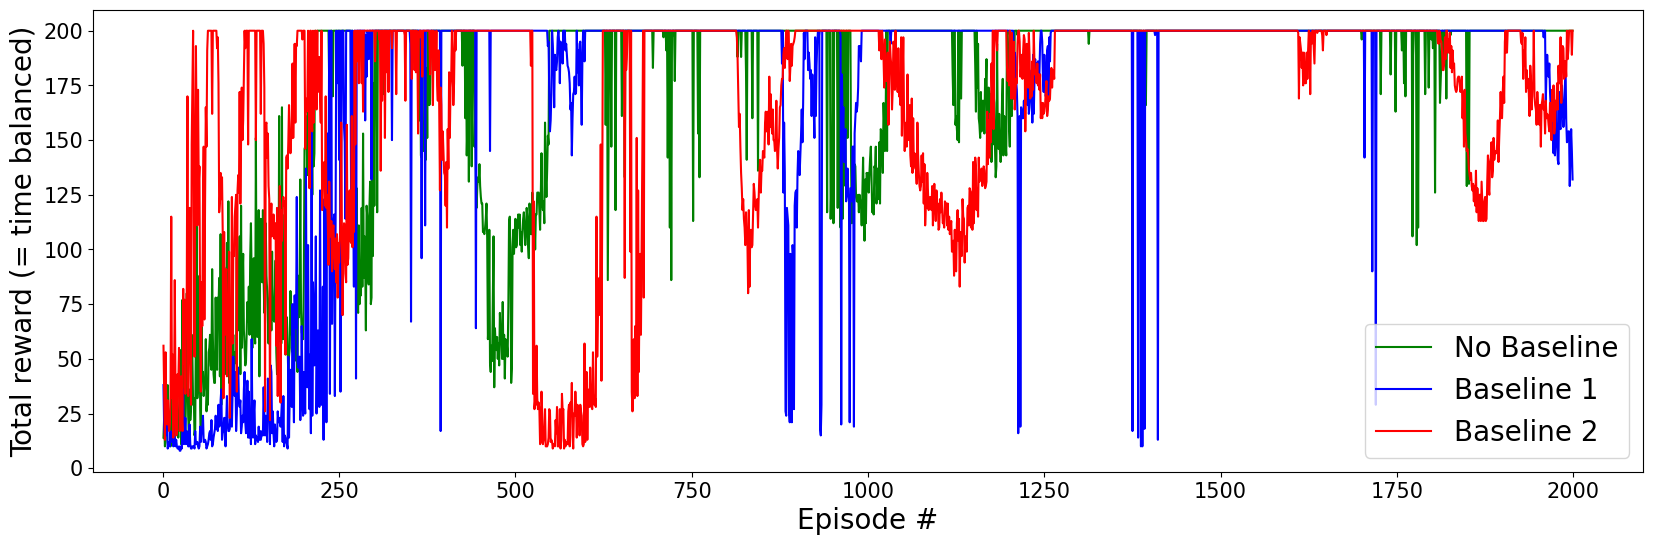

In [15]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')

# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)
***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:

$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$
***Question 2*** In this exercise, you will bound the state action counts. This is a crucial part of the OPPO convergence proof. Let $N^t_h(s,a)$ denotes the number of times the state action pair $s,a$ has been visited at step $h$ in all the episode up to $t$ included. Moreover,
let $s^t_h,a^t_h$ be the state action pair visited at step $h$ of the $t^{th}$ episode. Then, prove that 
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SAH \log( T H)$$
***Question 3*** Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)+1}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq H^2\sqrt{ SA T \log( T H)}$$